In [1]:
from data_siamese import get_test_transform
from model import SiameseNetwork
import torch
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np
import os
import torch.nn.functional as F
from sklearn.metrics import precision_recall_fscore_support

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/home/dungtn6/yenlb/signature_recognition/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dungtn6/yenlb/signature_recognition/.venv/lib/python3.8/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.0 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
def distance_with_real_set(model, img_path, real_img_paths):
    # Load and tranform an image to compare with the real set
    transform = get_test_transform()
    
    img = Image.open(img_path).convert('RGB')
    img = np.array(img)
    img = transform(image=img)['image'].unsqueeze(0)
    img = img.to(device)
    
    model.eval()
    distances = []
    with torch.no_grad():
        for filename in os.listdir(real_img_paths):
            real_img_path = os.path.join(real_img_paths, filename)
            real_img = Image.open(real_img_path).convert('RGB')
            real_img = np.array(real_img)
            real_img = transform(image=real_img)['image'].unsqueeze(0)
            real_img = real_img.to(device)
            
            img_embedding, real_img_embedding = model(img, real_img)
            distance =  F.pairwise_distance(img_embedding, real_img_embedding)
            distances.append(distance.item())

    avg_distance = sum(distances) / len(distances)
    return avg_distance

In [3]:
def tune_threshold(model, fake_img_folder, real_img_folder):
    model.eval()
    distances = []
    
    # Compute all distances between images in img_folder and real_img_folder
    for fake_img_filename in os.listdir(fake_img_folder):
        fake_img_path = os.path.join(fake_img_folder, fake_img_filename)
        avg_distance = distance_with_real_set(model, fake_img_path, real_img_folder)
        distances.append(avg_distance)

    for real_img_filename in os.listdir(real_img_folder):
        real_img_path = os.path.join(real_img_folder, real_img_filename)
        avg_distance = distance_with_real_set(model, real_img_path, real_img_folder)
        distances.append(avg_distance)

    # Determine the range of thresholds
    min_distance = min(distances)
    max_distance = max(distances)
    thresholds = np.linspace(min_distance, max_distance, num=10)
    
    best_threshold = None
    best_f1 = 0

    for threshold in thresholds:
        y_true = [] 
        y_pred = []

        # Loop through images in the folders
        for img_filename in os.listdir(fake_img_folder):
            img_path = os.path.join(fake_img_folder, img_filename)
            prediction = "Real" if distance_with_real_set(model, img_path, real_img_folder) < threshold else "Fake"
            y_true.append("Fake") 
            y_pred.append(prediction)

        for img_filename in os.listdir(real_img_folder):
            img_path = os.path.join(real_img_folder, img_filename)
            prediction = "Real" if distance_with_real_set(model, img_path, real_img_folder) < threshold else "Fake"
            y_true.append("Real") 
            y_pred.append(prediction)

        # Calculate precision, recall, and F1 score
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=["Real", "Fake"], average="binary", pos_label="Real", zero_division=1
        )

        print(f"Threshold: {threshold}, Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}")

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    print(f"Best Threshold: {best_threshold:.2f} with F1 Score: {best_f1:.2f}")
    return best_threshold

In [4]:
fake_img_folder = "./data/sign_match/infer/124_forg"
real_img_folder = "./data/sign_match/infer/124"

# Create model with different backbones and load weights from the best model
backbone = 'resnet50' # 'efficientnet_b0', 'efficientnet_b2', 'resnet18'
model = SiameseNetwork(model_name=backbone, pretrained=False)
model.load_state_dict(torch.load(f'weights/best_{backbone}_model.pth', weights_only=True))
model.to(device)

# Tune the threshold using F1 score
best_threshold = tune_threshold(model, fake_img_folder, real_img_folder)

Threshold: 531.0453553145442, Precision: 1.00, Recall: 0.00, F1: 0.00
Threshold: 1046.5352849558824, Precision: 1.00, Recall: 0.92, F1: 0.96
Threshold: 1562.0252145972206, Precision: 1.00, Recall: 1.00, F1: 1.00
Threshold: 2077.5151442385586, Precision: 1.00, Recall: 1.00, F1: 1.00
Threshold: 2593.0050738798973, Precision: 0.96, Recall: 1.00, F1: 0.98
Threshold: 3108.495003521235, Precision: 0.89, Recall: 1.00, F1: 0.94
Threshold: 3623.9849331625737, Precision: 0.80, Recall: 1.00, F1: 0.89
Threshold: 4139.4748628039115, Precision: 0.65, Recall: 1.00, F1: 0.79
Threshold: 4654.96479244525, Precision: 0.55, Recall: 1.00, F1: 0.71
Threshold: 5170.454722086589, Precision: 0.51, Recall: 1.00, F1: 0.68
Best Threshold: 1562.03 with F1 Score: 1.00


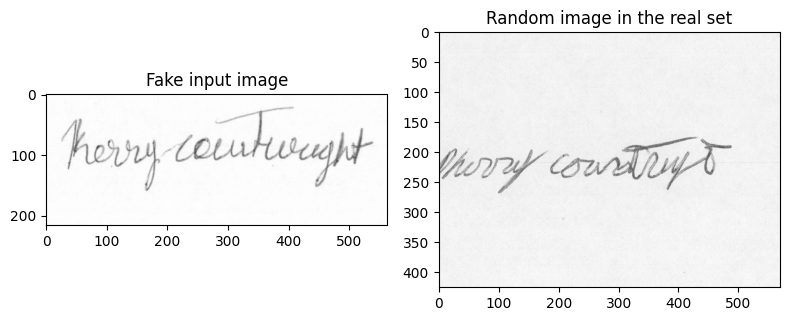

In [5]:
# Compare the input image to the real set to verify its authenticity
img_path = './data/sign_match/infer/124_forg/124_forg_22.png' # Change here
# img_path = './data/sign_match/infer/124/124_22.png' # Change here
real_img_paths = './data/sign_match/infer/124' # Change here
distance = distance_with_real_set(model, img_path, real_img_paths)
result = "Real" if distance < best_threshold else "Fake"
filenames = os.listdir(real_img_paths)
real_joined_img_paths = [os.path.join(real_img_paths, filename) for filename in filenames]

# Create figure of the image with result and a random image in the real set
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(Image.open(img_path))
ax[0].set_title(f'{result} input image')
ax[1].imshow(Image.open(random.choice(real_joined_img_paths)))
ax[1].set_title('Random image in the real set')
plt.tight_layout()
plt.show()